In [34]:
import pandas as pd

clinical_patient = pd.read_csv("/content/data_clinical_patient.txt", sep="\t", comment="#")
clinical_sample = pd.read_csv("/content/data_clinical_sample.txt", sep="\t", comment="#")
mutations = pd.read_csv("/content/data_mutations.txt", sep="\t", comment="#")
cna = pd.read_csv("/content/data_cna.txt", sep="\t", comment="#")
expr = pd.read_csv("/content/data_mrna_seq_v2_rsem.txt", sep="\t", comment="#")

/tmp/ipykernel_3689/1472493431.py:5: DtypeWarning: Columns (38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  mutations = pd.read_csv("/content/data_mutations.txt", sep="\t", comment="#")


In [35]:
clinical_patient.head()

,PATIENT_ID,SUBTYPE,CANCER_TYPE_ACRONYM,OTHER_PATIENT_ID,AGE,SEX,AJCC_PATHOLOGIC_TUMOR_STAGE,AJCC_STAGING_EDITION,DAYS_LAST_FOLLOWUP,DAYS_TO_BIRTH,...,IN_PANCANPATHWAYS_FREEZE,OS_STATUS,OS_MONTHS,DSS_STATUS,DSS_MONTHS,DFS_STATUS,DFS_MONTHS,PFS_STATUS,PFS_MONTHS,GENETIC_ANCESTRY_LABEL
0,TCGA-05-4244,LUAD,LUAD,34040b83-7e8a-4264-a551-b16621843e28,70.0,Male,STAGE IV,6TH,0.0,-25752.0,...,Yes,0:LIVING,0.000000,0:ALIVE OR DEAD TUMOR FREE,0.000000,NaN,NaN,0:CENSORED,0.000000,EUR
1,TCGA-05-4249,LUAD,LUAD,4addf05f-3668-4b3f-a17f-c0227329ca52,67.0,Male,STAGE IB,6TH,1523.0,-24532.0,...,Yes,0:LIVING,50.070684,0:ALIVE OR DEAD TUMOR FREE,50.070684,NaN,NaN,0:CENSORED,50.070684,EUR
2,TCGA-05-4250,LUAD,LUAD,f98ecd8a-b878-4f53-b911-20cd8e17281c,79.0,Female,STAGE IIIA,6TH,NaN,-29068.0,...,Yes,1:DECEASED,3.978039,NaN,3.978039,NaN,NaN,0:CENSORED,3.978039,EUR
3,TCGA-05-4382,LUAD,LUAD,3434b91a-c05f-460f-a078-7b1bb6e7085d,68.0,Male,STAGE IB,6TH,607.0,-24868.0,...,Yes,0:LIVING,19.955946,0:ALIVE OR DEAD TUMOR FREE,19.955946,1:Recurred/Progressed,10.980702,1:PROGRESSION,10.980702,EUR
4,TCGA-05-4384,LUAD,LUAD,9a50e7e4-831d-489f-87d2-979e987561cc,66.0,Male,STAGE IIIA,6TH,426.0,-24411.0,...,Yes,0:LIVING,14.005326,0:ALIVE OR DEAD TUMOR FREE,14.005326,NaN,NaN,1:PROGRESSION,6.016372,EUR


In [36]:
clinical = clinical_patient[['PATIENT_ID', 'OS_MONTHS', 'OS_STATUS']].copy()

clinical['OS_event'] = clinical['OS_STATUS'].apply(lambda x: 1 if 'DECEASED' in str(x) else 0)
clinical = clinical.rename(columns={'OS_MONTHS': 'OS_time'})

clinical.head()

,PATIENT_ID,OS_time,OS_STATUS,OS_event
0,TCGA-05-4244,0.000000,0:LIVING,0
1,TCGA-05-4249,50.070684,0:LIVING,0
2,TCGA-05-4250,3.978039,1:DECEASED,1
3,TCGA-05-4382,19.955946,0:LIVING,0
4,TCGA-05-4384,14.005326,0:LIVING,0


In [37]:
mutations.columns

Index(['Hugo_Symbol', 'Entrez_Gene_Id', 'Center', 'NCBI_Build', 'Chromosome',
       'Start_Position', 'End_Position', 'Strand', 'Consequence',
       'Variant_Classification',
       ...
       'SYMBOL_SOURCE', 'TREMBL', 'TSL', 'UNIPARC', 'VARIANT_CLASS',
       'all_effects', 'cDNA_position', 'n_depth', 't_depth',
       'Annotation_Status'],
      dtype='object', length=114)

In [38]:
'Tumor_Sample_Barcode' in mutations.columns

True

In [39]:
egfr_mut = mutations[mutations['Hugo_Symbol'] == 'EGFR']
egfr_mut = egfr_mut[['Tumor_Sample_Barcode']].drop_duplicates()
egfr_mut['EGFR_mut'] = 1
egfr_mut = egfr_mut.rename(columns={'Tumor_Sample_Barcode': 'SAMPLE_ID'})

egfr_mut.head()
egfr_mut.shape

(75, 2)

In [40]:
import pandas as pd

egfr_cna_raw = pd.read_csv('/content/data_cna.txt', sep='\t')
egfr_cna_raw.head()

,Hugo_Symbol,Entrez_Gene_Id,TCGA-05-4244-01,TCGA-05-4249-01,TCGA-05-4250-01,TCGA-05-4382-01,TCGA-05-4384-01,TCGA-05-4389-01,TCGA-05-4390-01,TCGA-05-4395-01,...,TCGA-NJ-A4YG-01,TCGA-NJ-A4YI-01,TCGA-NJ-A4YP-01,TCGA-NJ-A4YQ-01,TCGA-NJ-A55A-01,TCGA-NJ-A55O-01,TCGA-NJ-A55R-01,TCGA-NJ-A7XG-01,TCGA-O1-A52J-01,TCGA-S2-AA1A-01
0,ACAP3,116983.0,-1,-1,-1,0,0,-1,-1,0,...,0,0,0,-1,0,1,0,-1,-1,0
1,ACTRT2,140625.0,-1,-1,-1,0,0,-1,-1,0,...,0,0,0,-1,0,1,0,-1,-1,0
2,AGRN,375790.0,-1,-1,-1,0,0,-1,-1,0,...,0,0,0,-1,0,1,0,-1,-1,0
3,ANKRD65,441869.0,-1,-1,-1,0,0,-1,-1,0,...,0,0,0,-1,0,1,0,-1,-1,0
4,ATAD3A,55210.0,-1,-1,-1,0,0,-1,-1,0,...,0,0,0,-1,0,1,0,-1,-1,0


In [41]:
cna.head()
cna.columns[:5]

Index(['Hugo_Symbol', 'Entrez_Gene_Id', 'TCGA-05-4244-01', 'TCGA-05-4249-01',
       'TCGA-05-4250-01'],
      dtype='object')

In [42]:
print(egfr_cna.columns)
egfr_cna.head()

Index(['SAMPLE_ID', 'PATIENT_ID', 'EGFR_CNA'], dtype='object')


,SAMPLE_ID,PATIENT_ID,EGFR_CNA
0,TCGA-05-4244-01,TCGA-05-4244,-1
1,TCGA-05-4249-01,TCGA-05-4249,-1
2,TCGA-05-4250-01,TCGA-05-4250,1
3,TCGA-05-4382-01,TCGA-05-4382,1
4,TCGA-05-4384-01,TCGA-05-4384,0


In [43]:
import pandas as pd

# Load correctly
egfr_cna_raw = pd.read_csv('/content/data_cna.txt', sep='\t')

# Keep only EGFR row
egfr_cna = egfr_cna_raw[egfr_cna_raw['Hugo_Symbol'] == 'EGFR'].copy()

# Convert wide -> long
egfr_cna = egfr_cna.melt(
    id_vars=['Hugo_Symbol', 'Entrez_Gene_Id'],
    var_name='SAMPLE_ID',
    value_name='EGFR_CNA'
)

# Add patient ID
egfr_cna['PATIENT_ID'] = egfr_cna['SAMPLE_ID'].str[:12]

# Keep only needed columns
egfr_cna = egfr_cna[['SAMPLE_ID', 'PATIENT_ID', 'EGFR_CNA']]

egfr_cna.head()

,SAMPLE_ID,PATIENT_ID,EGFR_CNA
0,TCGA-05-4244-01,TCGA-05-4244,-1
1,TCGA-05-4249-01,TCGA-05-4249,-1
2,TCGA-05-4250-01,TCGA-05-4250,1
3,TCGA-05-4382-01,TCGA-05-4382,1
4,TCGA-05-4384-01,TCGA-05-4384,0


In [44]:
expr = expr.set_index('Hugo_Symbol')

egfr_expr = expr.loc['EGFR']
egfr_expr = egfr_expr.reset_index()
egfr_expr.columns = ['SAMPLE_ID', 'EGFR_expr']

egfr_expr['PATIENT_ID'] = egfr_expr['SAMPLE_ID'].str[:12]

egfr_expr.head()
egfr_expr.shape

(511, 3)

In [45]:
egfr_mut['PATIENT_ID'] = egfr_mut['SAMPLE_ID'].str[:12]
egfr_mut.head()

,SAMPLE_ID,EGFR_mut,PATIENT_ID
2898,TCGA-05-4382-01,1,TCGA-05-4382
8572,TCGA-05-4402-01,1,TCGA-05-4402
10468,TCGA-05-4410-01,1,TCGA-05-4410
15720,TCGA-05-5423-01,1,TCGA-05-5423
24681,TCGA-17-Z026-01,1,TCGA-17-Z026


In [46]:
final_df = clinical.merge(
    egfr_cna[['PATIENT_ID', 'EGFR_CNA']],
    on='PATIENT_ID',
    how='left'
)

final_df = final_df.merge(
    egfr_expr[['PATIENT_ID', 'EGFR_expr']],
    on='PATIENT_ID',
    how='left'
)

final_df = final_df.merge(
    egfr_mut[['PATIENT_ID', 'EGFR_mut']],
    on='PATIENT_ID',
    how='left'
)

final_df['EGFR_mut'] = final_df['EGFR_mut'].fillna(0)

final_df.head()
final_df.shape

(566, 7)

In [47]:
final_df['EGFR_CNA'] = pd.to_numeric(final_df['EGFR_CNA'], errors='coerce')
final_df['EGFR_expr'] = pd.to_numeric(final_df['EGFR_expr'], errors='coerce')
final_df['OS_time'] = pd.to_numeric(final_df['OS_time'], errors='coerce')

model_df = final_df[['EGFR_mut', 'EGFR_CNA', 'EGFR_expr', 'OS_time', 'OS_event']].dropna()

model_df.head()
model_df.shape

(498, 5)

In [48]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 13.8 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=a016f2c9ede5323a67b90df0d087db9c9a27dbea3d64d15a4e04054cad6837b1
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [49]:
from lifelines import CoxPHFitter

cph = CoxPHFitter()
cph.fit(model_df, duration_col='OS_time', event_col='OS_event')
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 498 total observations, 320 right-censored observations>
             duration col = 'OS_time'
                event col = 'OS_event'
      baseline estimation = breslow
   number of observations = 498
number of events observed = 178
   partial log-likelihood = -944.60
         time fit was run = 2026-03-22 04:48:22 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
EGFR_mut   0.09      1.09      0.22           -0.33            0.51                0.72                1.66
EGFR_CNA   0.19      1.21      0.12           -0.05            0.43                0.95                1.54
EGFR_expr  0.00      1.00      0.00           -0.00            0.00                1.00                1.00

           cmp to    z    p  -log2(p)
covariate                            
EGFR_mut     0.00 0.41 0.68      0.55
EGFR_CNA     0.00 1.55 0.12      3.03
EGFR_expr    0.00 1.56 0.12      3.08
---
Concordance = 0.54
Partial AIC = 1895.21
log-likelihood ratio test = 8.41 on 3 df
-log2(p) of ll-ratio test = 4.71

In [50]:
egfr_cna = egfr_cna[egfr_cna['SAMPLE_ID'] != 'Entrez_Gene_Id']
egfr_expr = egfr_expr[egfr_expr['SAMPLE_ID'] != 'Entrez_Gene_Id']

In [51]:
# =========================
# 1. Import libraries
# =========================
import pandas as pd

# Install lifelines if not already installed
try:
    from lifelines import CoxPHFitter
except ImportError:
    !pip install lifelines -q
    from lifelines import CoxPHFitter

# =========================
# 2. File paths
# =========================
clinical_patient_path = "/content/data_clinical_patient.txt"
clinical_sample_path = "/content/data_clinical_sample.txt"
cna_path = "/content/data_cna.txt"
expr_path = "/content/data_mrna_seq_v2_rsem.txt"
mutations_path = "/content/data_mutations.txt"

# =========================
# 3. Load data
# =========================
clinical_patient = pd.read_csv(clinical_patient_path, sep="\t", comment="#")
clinical_sample = pd.read_csv(clinical_sample_path, sep="\t", comment="#")
cna = pd.read_csv(cna_path, sep="\t", comment="#")
expr = pd.read_csv(expr_path, sep="\t", comment="#")
mutations = pd.read_csv(mutations_path, sep="\t", comment="#")

print("clinical_patient:", clinical_patient.shape)
print("clinical_sample :", clinical_sample.shape)
print("cna             :", cna.shape)
print("expr            :", expr.shape)
print("mutations       :", mutations.shape)

# =========================
# 4. Clinical survival data
# =========================
clinical = clinical_patient[['PATIENT_ID', 'OS_MONTHS', 'OS_STATUS']].copy()
clinical['OS_event'] = clinical['OS_STATUS'].apply(lambda x: 1 if 'DECEASED' in str(x) else 0)
clinical = clinical.rename(columns={'OS_MONTHS': 'OS_time'})

print("\nClinical survival preview:")
print(clinical.head())

# =========================
# 5. Extended clinical covariates
# =========================
clinical_extended = clinical_patient[['PATIENT_ID', 'AGE', 'SEX', 'AJCC_PATHOLOGIC_TUMOR_STAGE']].copy()

# Encode sex
clinical_extended['SEX'] = clinical_extended['SEX'].map({'Male': 1, 'Female': 0})

# Map stage to numeric
stage_map = {
    'STAGE I': 1, 'STAGE IA': 1, 'STAGE IB': 1,
    'STAGE II': 2, 'STAGE IIA': 2, 'STAGE IIB': 2,
    'STAGE III': 3, 'STAGE IIIA': 3, 'STAGE IIIB': 3, 'STAGE IIIC': 3,
    'STAGE IV': 4
}
clinical_extended['STAGE_NUM'] = clinical_extended['AJCC_PATHOLOGIC_TUMOR_STAGE'].map(stage_map)

print("\nExtended clinical preview:")
print(clinical_extended.head())

# =========================
# 6. EGFR mutation extraction
# =========================
egfr_mut = mutations[mutations['Hugo_Symbol'] == 'EGFR'][['Tumor_Sample_Barcode']].drop_duplicates().copy()
egfr_mut['EGFR_mut'] = 1
egfr_mut = egfr_mut.rename(columns={'Tumor_Sample_Barcode': 'SAMPLE_ID'})
egfr_mut['PATIENT_ID'] = egfr_mut['SAMPLE_ID'].str[:12]

print("\nEGFR mutation preview:")
print(egfr_mut.head())
print("EGFR mutated samples:", egfr_mut.shape[0])

# =========================
# 7. EGFR CNA extraction
# =========================
cna = cna.set_index('Hugo_Symbol')

egfr_cna = cna.loc['EGFR'].reset_index()
egfr_cna.columns = ['SAMPLE_ID', 'EGFR_CNA']
egfr_cna['PATIENT_ID'] = egfr_cna['SAMPLE_ID'].str[:12]

print("\nEGFR CNA preview:")
print(egfr_cna.head())
print("EGFR CNA rows:", egfr_cna.shape[0])

# =========================
# 8. EGFR expression extraction
# =========================
expr = expr.set_index('Hugo_Symbol')

egfr_expr = expr.loc['EGFR'].reset_index()
egfr_expr.columns = ['SAMPLE_ID', 'EGFR_expr']
egfr_expr['PATIENT_ID'] = egfr_expr['SAMPLE_ID'].str[:12]

print("\nEGFR expression preview:")
print(egfr_expr.head())
print("EGFR expression rows:", egfr_expr.shape[0])

# =========================
# 9. Merge all data
# =========================
final_df = clinical.merge(
    egfr_cna[['PATIENT_ID', 'EGFR_CNA']],
    on='PATIENT_ID',
    how='left'
)

final_df = final_df.merge(
    egfr_expr[['PATIENT_ID', 'EGFR_expr']],
    on='PATIENT_ID',
    how='left'
)

final_df = final_df.merge(
    egfr_mut[['PATIENT_ID', 'EGFR_mut']],
    on='PATIENT_ID',
    how='left'
)

final_df = final_df.merge(
    clinical_extended[['PATIENT_ID', 'AGE', 'SEX', 'STAGE_NUM']],
    on='PATIENT_ID',
    how='left'
)

final_df['EGFR_mut'] = final_df['EGFR_mut'].fillna(0)

# High vs low expression
final_df['EGFR_expr'] = pd.to_numeric(final_df['EGFR_expr'], errors='coerce')
final_df['EGFR_expr_high'] = (final_df['EGFR_expr'] > final_df['EGFR_expr'].median()).astype(int)

# Convert numeric columns
final_df['EGFR_CNA'] = pd.to_numeric(final_df['EGFR_CNA'], errors='coerce')
final_df['OS_time'] = pd.to_numeric(final_df['OS_time'], errors='coerce')
final_df['AGE'] = pd.to_numeric(final_df['AGE'], errors='coerce')
final_df['SEX'] = pd.to_numeric(final_df['SEX'], errors='coerce')
final_df['STAGE_NUM'] = pd.to_numeric(final_df['STAGE_NUM'], errors='coerce')

print("\nFinal merged dataset preview:")
print(final_df.head())
print("Final merged shape:", final_df.shape)

# =========================
# 10. Build modelling dataset
# =========================
model_df = final_df[
    ['EGFR_mut', 'EGFR_CNA', 'EGFR_expr_high', 'AGE', 'SEX', 'STAGE_NUM', 'OS_time', 'OS_event']
].dropna().copy()

print("\nModel dataset preview:")
print(model_df.head())
print("Model dataset shape:", model_df.shape)

# =========================
# 11. Run adjusted Cox model
# =========================
cph = CoxPHFitter()
cph.fit(model_df, duration_col='OS_time', event_col='OS_event')

print("\n===== Cox Model Summary =====")
cph.print_summary()

# =========================
# 12. Optional: save cleaned dataset
# =========================
final_df.to_csv("/content/luad_egfr_survival_dataset.csv", index=False)
print("\nSaved cleaned dataset to: /content/luad_egfr_survival_dataset.csv")

/tmp/ipykernel_3689/3207883066.py:29: DtypeWarning: Columns (38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  mutations = pd.read_csv(mutations_path, sep="\t", comment="#")


clinical_patient: (566, 38)
clinical_sample : (566, 19)
cna             : (25128, 513)
expr            : (20531, 512)
mutations       : (243229, 114)

Clinical survival preview:
     PATIENT_ID    OS_time   OS_STATUS  OS_event
0  TCGA-05-4244   0.000000    0:LIVING         0
1  TCGA-05-4249  50.070684    0:LIVING         0
2  TCGA-05-4250   3.978039  1:DECEASED         1
3  TCGA-05-4382  19.955946    0:LIVING         0
4  TCGA-05-4384  14.005326    0:LIVING         0

Extended clinical preview:
     PATIENT_ID   AGE  SEX AJCC_PATHOLOGIC_TUMOR_STAGE  STAGE_NUM
0  TCGA-05-4244  70.0  1.0                    STAGE IV        4.0
1  TCGA-05-4249  67.0  1.0                    STAGE IB        1.0
2  TCGA-05-4250  79.0  0.0                  STAGE IIIA        3.0
3  TCGA-05-4382  68.0  1.0                    STAGE IB        1.0
4  TCGA-05-4384  66.0  1.0                  STAGE IIIA        3.0

EGFR mutation preview:
             SAMPLE_ID  EGFR_mut    PATIENT_ID
2898   TCGA-05-4382-01         1 

<lifelines.CoxPHFitter: fitted with 490 total observations, 314 right-censored observations>
             duration col = 'OS_time'
                event col = 'OS_event'
      baseline estimation = breslow
   number of observations = 490
number of events observed = 176
   partial log-likelihood = -906.78
         time fit was run = 2026-03-22 04:48:30 UTC

---
                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                       
EGFR_mut       -0.12      0.89      0.23           -0.57            0.33                0.57                1.39
EGFR_CNA        0.34      1.41      0.12            0.10            0.58                1.11                1.79
EGFR_expr_high -0.11      0.90      0.17           -0.44            0.23                0.64                1.25
AGE             0.02      1.02      0.01            0.00            0.03                1.00                1.03
SEX             0.04      1.05      0.16           -0.27            0.36                0.76                1.43
STAGE_NUM       0.51      1.67      0.08            0.36            0.66                1.44                1.93

                cmp to     z      p  -log2(p)
covariate                                    
EGFR_mut          0.00 -0.53   0.60      0.75
EGFR_CNA          0.00  2.81   0.01      7.64
EGFR_expr_high    0.00 -0.62   0.53      0.91
AGE               0.00  2.21   0.03      5.20
SEX               0.00  0.28   0.78      0.36
STAGE_NUM         0.00  6.79 <0.005     36.40
---
Concordance = 0.68
Partial AIC = 1825.55
log-likelihood ratio test = 51.45 on 6 df
-log2(p) of ll-ratio test = 28.63


Saved cleaned dataset to: /content/luad_egfr_survival_dataset.csv


In [52]:
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# Make sure final_df exists from your pipeline

# Define CNA groups
final_df['EGFR_CNA_group'] = final_df['EGFR_CNA'].apply(lambda x: 'Amplified' if x >= 1 else 'Non-Amplified')

# Drop missing values
km_df = final_df[['OS_time', 'OS_event', 'EGFR_CNA_group']].dropna()

km_df.head()

,OS_time,OS_event,EGFR_CNA_group
0,0.000000,0,Non-Amplified
1,50.070684,0,Non-Amplified
2,3.978039,1,Amplified
3,19.955946,0,Amplified
4,14.005326,0,Non-Amplified


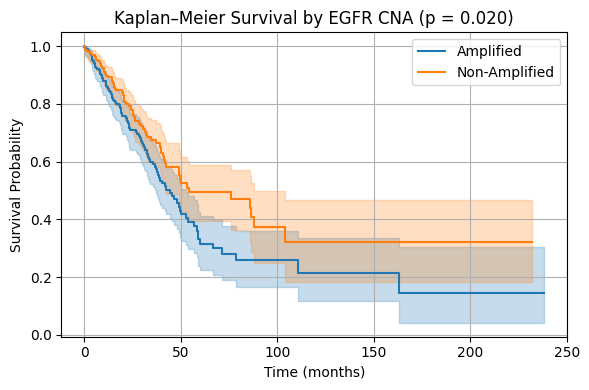

In [53]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()

plt.figure(figsize=(6,4))

for group in ['Amplified', 'Non-Amplified']:
    mask = km_df['EGFR_CNA_group'] == group
    kmf.fit(km_df[mask]['OS_time'],
            event_observed=km_df[mask]['OS_event'],
            label=group)
    kmf.plot_survival_function(ci_show=True)

# Log-rank test
group1 = km_df[km_df['EGFR_CNA_group'] == 'Amplified']
group2 = km_df[km_df['EGFR_CNA_group'] == 'Non-Amplified']

results = logrank_test(
    group1['OS_time'], group2['OS_time'],
    event_observed_A=group1['OS_event'],
    event_observed_B=group2['OS_event']
)

p_value = results.p_value

plt.title(f'Kaplan–Meier Survival by EGFR CNA (p = {p_value:.3f})')
plt.xlabel('Time (months)')
plt.ylabel('Survival Probability')

plt.grid(True)
plt.tight_layout()
plt.savefig('/content/egfr_cna_km_final.png', dpi=300)
plt.show()

In [54]:
group1 = km_df[km_df['EGFR_CNA_group'] == 'Amplified']
group2 = km_df[km_df['EGFR_CNA_group'] == 'Non-Amplified']

results = logrank_test(
    group1['OS_time'], group2['OS_time'],
    event_observed_A=group1['OS_event'],
    event_observed_B=group2['OS_event']
)

print("Log-rank p-value:", results.p_value)

Log-rank p-value: 0.019901825412683295


#Prepare the final modelling dataframe

In [55]:
import pandas as pd
import numpy as np

# Copy to avoid accidental overwrite
analysis_df = final_df.copy()

# Ensure numeric
analysis_df['EGFR_mut'] = pd.to_numeric(analysis_df['EGFR_mut'], errors='coerce')
analysis_df['EGFR_CNA'] = pd.to_numeric(analysis_df['EGFR_CNA'], errors='coerce')
analysis_df['EGFR_expr'] = pd.to_numeric(analysis_df['EGFR_expr'], errors='coerce')
analysis_df['AGE'] = pd.to_numeric(analysis_df['AGE'], errors='coerce')
analysis_df['SEX'] = pd.to_numeric(analysis_df['SEX'], errors='coerce')
analysis_df['STAGE_NUM'] = pd.to_numeric(analysis_df['STAGE_NUM'], errors='coerce')
analysis_df['OS_time'] = pd.to_numeric(analysis_df['OS_time'], errors='coerce')
analysis_df['OS_event'] = pd.to_numeric(analysis_df['OS_event'], errors='coerce')

# Binary expression
analysis_df['EGFR_expr_high'] = (analysis_df['EGFR_expr'] > analysis_df['EGFR_expr'].median()).astype(int)

# CNA group for KM analysis
analysis_df['EGFR_CNA_group'] = np.where(analysis_df['EGFR_CNA'] >= 1, 'Amplified', 'Non-Amplified')

# Main model dataframe
model_df = analysis_df[
    ['EGFR_mut', 'EGFR_CNA', 'EGFR_expr_high', 'AGE', 'SEX', 'STAGE_NUM', 'OS_time', 'OS_event']
].dropna().copy()

print(model_df.shape)
model_df.head()

(490, 8)


,EGFR_mut,EGFR_CNA,EGFR_expr_high,AGE,SEX,STAGE_NUM,OS_time,OS_event
0,0.0,-1.0,1,70.0,1.0,4.0,0.000000,0
1,0.0,-1.0,1,67.0,1.0,1.0,50.070684,0
2,0.0,1.0,0,79.0,0.0,3.0,3.978039,1
3,1.0,1.0,0,68.0,1.0,1.0,19.955946,0
4,0.0,0.0,0,66.0,1.0,3.0,14.005326,0


#Univariate Cox for each variable

In [56]:
from lifelines import CoxPHFitter

univariate_vars = ['EGFR_mut', 'EGFR_CNA', 'EGFR_expr_high', 'AGE', 'SEX', 'STAGE_NUM']

uni_results = []

for var in univariate_vars:
    tmp = model_df[[var, 'OS_time', 'OS_event']].dropna().copy()
    cph_uni = CoxPHFitter()
    cph_uni.fit(tmp, duration_col='OS_time', event_col='OS_event')

    s = cph_uni.summary.loc[var]
    uni_results.append({
        'Variable': var,
        'HR': s['exp(coef)'],
        'CI_lower': s['exp(coef) lower 95%'],
        'CI_upper': s['exp(coef) upper 95%'],
        'p_value': s['p']
    })

univariate_table = pd.DataFrame(uni_results)
univariate_table

,Variable,HR,CI_lower,CI_upper,p_value
0,EGFR_mut,1.294332,0.857222,1.954329,2.197571e-01
1,EGFR_CNA,1.269615,1.017013,1.584958,3.494396e-02
2,EGFR_expr_high,1.023264,0.760718,1.376422,8.791660e-01
3,AGE,1.009482,0.994048,1.025156,2.299412e-01
4,SEX,1.142742,0.849859,1.536560,3.771448e-01
5,STAGE_NUM,1.625290,1.410882,1.872281,1.710953e-11


In [58]:
cph.check_assumptions(model_df, p_value_threshold=0.05, show_plots=False)

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'SEX' failed the non-proportional test: p-value is 0.0239.

   Advice: with so few unique values (only 2), you can include `strata=['SEX', ...]` in the call in
`.fit`. See documentation in link [E] below.

---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Introduce-time-varying-covariates
[D]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Modify-the-functional-form
[E]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Stratification



[]

In [60]:
km_group_summary = analysis_df[['EGFR_CNA_group', 'OS_event']].dropna().groupby('EGFR_CNA_group').agg(
    n_patients=('OS_event', 'size'),
    n_events=('OS_event', 'sum')
).reset_index()

km_group_summary
km_group_summary['event_rate_percent'] = (km_group_summary['n_events'] / km_group_summary['n_patients'] * 100).round(1)
km_group_summary

,EGFR_CNA_group,n_patients,n_events,event_rate_percent
0,Amplified,269,111,41.3
1,Non-Amplified,297,75,25.3


#Median overall survival by CNA group

In [61]:
from lifelines import KaplanMeierFitter

km_medians = []

for group in ['Amplified', 'Non-Amplified']:
    tmp = analysis_df[analysis_df['EGFR_CNA_group'] == group][['OS_time', 'OS_event']].dropna()
    kmf = KaplanMeierFitter()
    kmf.fit(tmp['OS_time'], event_observed=tmp['OS_event'], label=group)

    km_medians.append({
        'Group': group,
        'Median_OS_months': kmf.median_survival_time_
    })

median_os_table = pd.DataFrame(km_medians)
median_os_table

,Group,Median_OS_months
0,Amplified,44.61321
1,Non-Amplified,54.34461


#Log-rank test again for reporting

In [62]:
from lifelines.statistics import logrank_test

amp = analysis_df[analysis_df['EGFR_CNA_group'] == 'Amplified'][['OS_time', 'OS_event']].dropna()
nonamp = analysis_df[analysis_df['EGFR_CNA_group'] == 'Non-Amplified'][['OS_time', 'OS_event']].dropna()

logrank_res = logrank_test(
    amp['OS_time'], nonamp['OS_time'],
    event_observed_A=amp['OS_event'],
    event_observed_B=nonamp['OS_event']
)

print("Log-rank p-value:", logrank_res.p_value)
print("Amplified n =", len(amp), ", events =", int(amp['OS_event'].sum()))
print("Non-Amplified n =", len(nonamp), ", events =", int(nonamp['OS_event'].sum()))

Log-rank p-value: 0.019901825412683295
Amplified n = 263 , events = 107
Non-Amplified n = 242 , events = 75


#Forest plot for multivariable Cox model

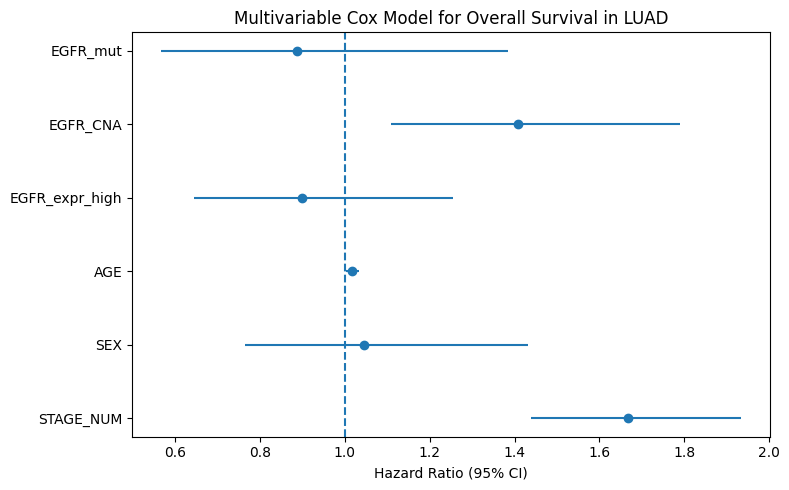

In [63]:
import matplotlib.pyplot as plt

forest_df = cph.summary.reset_index().rename(columns={'covariate': 'Variable'})
forest_df = forest_df[['Variable', 'exp(coef)', 'exp(coef) lower 95%', 'exp(coef) upper 95%']].copy()
forest_df.columns = ['Variable', 'HR', 'CI_lower', 'CI_upper']

# Reverse for better top-down display
forest_df = forest_df.iloc[::-1].reset_index(drop=True)

plt.figure(figsize=(8, 5))
y_pos = range(len(forest_df))

plt.errorbar(
    forest_df['HR'],
    y_pos,
    xerr=[forest_df['HR'] - forest_df['CI_lower'], forest_df['CI_upper'] - forest_df['HR']],
    fmt='o'
)

plt.axvline(x=1, linestyle='--')
plt.yticks(y_pos, forest_df['Variable'])
plt.xlabel('Hazard Ratio (95% CI)')
plt.title('Multivariable Cox Model for Overall Survival in LUAD')
plt.tight_layout()
plt.savefig('/content/forest_plot_luad_cox.png', dpi=300)
plt.show()